In [3]:
!pip install openpyxl

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"

df = pd.read_excel(url)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Dataset shape: (541909, 8)

Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [6]:
print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [7]:
print("Duplicate records:", df.duplicated().sum())

Duplicate records: 5268


In [8]:
df = df.dropna(subset=["Description", "CustomerID"])

df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

df = df[df["Quantity"] > 0]

df = df[df["UnitPrice"] > 0]

df = df.drop_duplicates()

print("Cleaned dataset:", df.shape)

Cleaned dataset: (392692, 8)


In [9]:
popular_products = df["Description"].value_counts().head(10)

print(popular_products)

Description
WHITE HANGING HEART T-LIGHT HOLDER    2016
REGENCY CAKESTAND 3 TIER              1713
JUMBO BAG RED RETROSPOT               1615
ASSORTED COLOUR BIRD ORNAMENT         1395
PARTY BUNTING                         1389
LUNCH BAG RED RETROSPOT               1303
SET OF 3 CAKE TINS PANTRY DESIGN      1152
POSTAGE                               1099
LUNCH BAG  BLACK SKULL.               1078
PACK OF 72 RETROSPOT CAKE CASES       1050
Name: count, dtype: int64


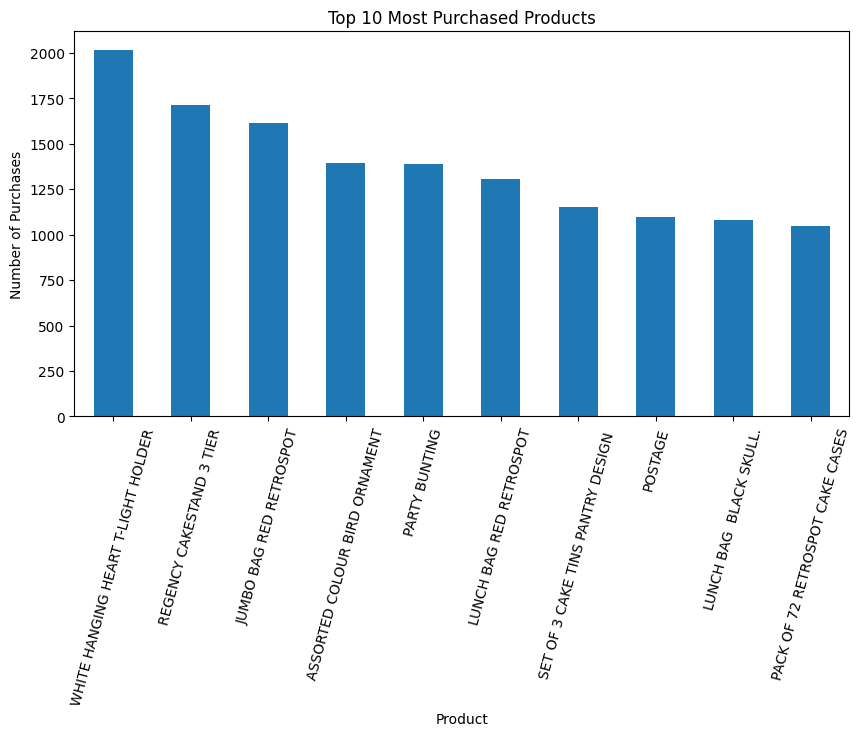

In [10]:
popular_products.plot(kind="bar", figsize=(10, 5))

plt.title("Top 10 Most Purchased Products")
plt.xlabel("Product")
plt.ylabel("Number of Purchases")
plt.xticks(rotation=75)

plt.show()

In [11]:
customer_product = df.pivot_table(
    index="CustomerID",
    columns="Description",
    values="Quantity",
    aggfunc="sum",
    fill_value=0
)

customer_product.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12347.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12349.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12350.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
from sklearn.metrics.pairwise import cosine_similarity

product_similarity = cosine_similarity(customer_product.T)

print("Product similarity model created successfully.")

Product similarity model created successfully.


In [13]:
def recommend_products(product_name, number_of_recommendations=5):

    if product_name not in customer_product.columns:
        print("Product not found.")
        return

    product_index = customer_product.columns.get_loc(product_name)

    similarity_scores = product_similarity[product_index]

    similar_products = pd.Series(
        similarity_scores,
        index=customer_product.columns
    )

    similar_products = similar_products.drop(product_name)

    return similar_products.sort_values(
        ascending=False
    ).head(number_of_recommendations)

In [14]:
sample_product = df["Description"].iloc[0]

print("Selected product:", sample_product)

Selected product: WHITE HANGING HEART T-LIGHT HOLDER


In [15]:
recommendations = recommend_products(sample_product, 5)

print("\nRecommended products:")
print(recommendations)


Recommended products:
Description
GIN + TONIC DIET METAL SIGN         0.750192
RED HANGING HEART T-LIGHT HOLDER    0.658714
WASHROOM METAL SIGN                 0.643520
LAUNDRY 15C METAL SIGN              0.642200
GREEN VINTAGE SPOT BEAKER           0.631463
dtype: float64


In [16]:
for product in recommendations.index:
    print(product)

GIN + TONIC DIET METAL SIGN
RED HANGING HEART T-LIGHT HOLDER
WASHROOM METAL SIGN
LAUNDRY 15C METAL SIGN
GREEN VINTAGE SPOT BEAKER


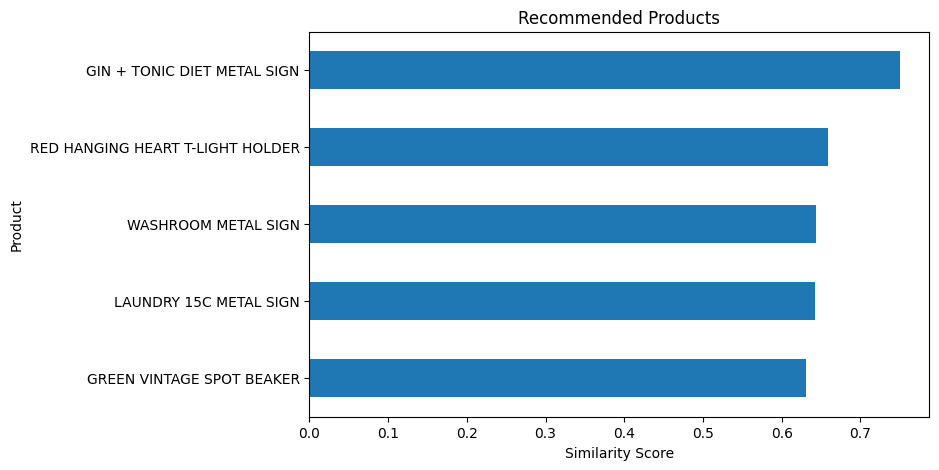

In [17]:
recommendations.sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Recommended Products")
plt.xlabel("Similarity Score")
plt.ylabel("Product")

plt.show()

In [18]:
print("E-commerce Product Recommendation Analysis Completed Successfully.")
print("Customer purchasing patterns were analyzed.")
print("Popular products were identified.")
print("A product similarity model was created.")
print("Product recommendations were generated.")

E-commerce Product Recommendation Analysis Completed Successfully.
Customer purchasing patterns were analyzed.
Popular products were identified.
A product similarity model was created.
Product recommendations were generated.
